In [1]:
import pandas as pd
from pathlib import Path
import re

In [2]:
# datadir = Path("/home/ebelm/genomegraph/data/20250408_STREME_benchmark_revisited")
datadir = Path("/home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited") # local
# wd = Path("/home/ebelm/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles")
wd = Path("/home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles") # local

assert datadir.exists(), f"Data directory {datadir} does not exist"
assert (datadir / "jolma2013.meme").exists(), f"Jolma motifs file {datadir / 'jolma2013.meme'} does not exist"
assert (datadir / "simulated_dataset").exists(), f"Data directory {datadir / 'simulated_dataset'} does not exist"
order_dirs = list((datadir / "simulated_dataset").glob("order_*"))
assert len(order_dirs) > 0, f"No order directories found in {datadir}"

print(f"Data directory: {datadir}")
print(f"Order directories: {[d.name for d in order_dirs]}")
print(f"Working directory: {wd}")

Data directory: /home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited
Order directories: ['order_0', 'order_2', 'order_1', 'order_3']
Working directory: /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles


In [3]:
# check for expected runs
run_stats = {
    'order': [],
    'mode': [],
    'mfreq': [],
    'simexp': [],
    'has_run': [],
    'has_pf_output': [],
    'has_pf_init_output': [],
    'has_streme_output': [],
}
for order_dir in order_dirs:
    mode_dirs = list([d for d in order_dir.glob("*") if d.is_dir()])
    assert len(mode_dirs) > 0, f"No mode directories found in {order_dir}"
    print(f"Checking order directory: {order_dir.name} with {len(mode_dirs)} mode directories")
    for midx, mode_dir in enumerate(mode_dirs):
        assert (mode_dir / "target_reference_motifs_simulated.tsv").exists(), \
            f"Reference motifs file {mode_dir / 'target_reference_motifs_simulated.tsv'} does not exist"
        refs_simulated = pd.read_csv(mode_dir / "target_reference_motifs_simulated.tsv", 
                                        sep="\t", names=['file', 'ref'])
        assert len(refs_simulated) == 1, f"Expected 1 reference motif file, found {refs_simulated}"
        simexp = refs_simulated['file'].values[0]
        print(f"Checking mode {mode_dir.name} ({midx+1}/{len(mode_dirs)})")
        for mfreq in mode_dir.iterdir():
            if mfreq.is_dir():
                experiment_dir = wd / order_dir.name / mode_dir.name / mfreq.name
                assert experiment_dir.exists(), f"Experiment directory {experiment_dir} does not exist"
                assert (experiment_dir / "run_STREME.sh").exists(), \
                    f"Run script {experiment_dir / 'run_STREME.sh'} does not exist"
                run_stats['order'].append(order_dir.name)
                run_stats['mode'].append(mode_dir.name)
                run_stats['mfreq'].append(mfreq.name)
                run_stats['simexp'].append(simexp)
                rundir = experiment_dir / simexp
                if not rundir.exists():
                    print(f"Run directory {rundir} does not exist")
                    run_stats['has_run'].append(False)
                    run_stats['has_pf_output'].append(False)
                    run_stats['has_pf_init_output'].append(False)
                    run_stats['has_streme_output'].append(False)
                    continue
                run_stats['has_run'].append(True)

                pf_output = rundir / "profilefinding" / "tomtom" / "tomtom.tsv"
                pf_init_output = rundir / "profilefinding_init" / "tomtom" / "tomtom.tsv"
                streme_output = rundir / "streme" / "tomtom" / "tomtom.tsv"
                if pf_output.exists():
                    run_stats['has_pf_output'].append(True)
                else:
                    run_stats['has_pf_output'].append(False)
                if pf_init_output.exists():
                    run_stats['has_pf_init_output'].append(True)
                else:
                    run_stats['has_pf_init_output'].append(False)
                if streme_output.exists():
                    run_stats['has_streme_output'].append(True)
                else:
                    run_stats['has_streme_output'].append(False)

# create dataframe
run_stats_df = pd.DataFrame(run_stats)

# create summary dataframe per order and mode
summary_stats = {
    'order': [],
    'mode': [],
    'n_runs': [],
    'n_executed': [],
    'n_pf_output': [],
    'n_pf_init_output': [],
    'n_streme_output': [],
}
for order in sorted(run_stats_df['order'].unique()):
    for mode in sorted(run_stats_df[run_stats_df['order'] == order]['mode'].unique()):
        order_mode_df = run_stats_df[(run_stats_df['order'] == order) & (run_stats_df['mode'] == mode)]
        if len(order_mode_df) == 0:
            continue
        summary_stats['order'].append(order)
        summary_stats['mode'].append(mode)
        summary_stats['n_runs'].append(len(order_mode_df))
        summary_stats['n_executed'].append(order_mode_df['has_run'].sum())
        summary_stats['n_pf_output'].append(order_mode_df['has_pf_output'].sum())
        summary_stats['n_pf_init_output'].append(order_mode_df['has_pf_init_output'].sum())
        summary_stats['n_streme_output'].append(order_mode_df['has_streme_output'].sum())

summary_stats_df = pd.DataFrame(summary_stats)

Checking order directory: order_0 with 2 mode directories
Checking mode wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak (1/2)
Checking mode uniform (2/2)
Checking order directory: order_2 with 2 mode directories
Checking mode wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak (1/2)
Checking mode uniform (2/2)
Checking order directory: order_1 with 3 mode directories
Checking mode wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak (1/3)
Checking mode uniform (2/3)
Checking mode augustus (3/3)
Checking order directory: order_3 with 2 mode directories
Checking mode wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak (1/2)
Checking mode uniform (2/2)


In [4]:
summary_stats_df

,order,mode,n_runs,n_executed,n_pf_output,n_pf_init_output,n_streme_output
0,order_0,uniform,11,11,11,11,11
1,order_0,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,11,11,11,11,11
2,order_1,augustus,11,11,11,11,11
3,order_1,uniform,11,11,11,11,11
4,order_1,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,11,11,11,11,11
5,order_2,uniform,11,11,11,11,11
6,order_2,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,11,11,11,11,11
7,order_3,uniform,11,11,11,11,11
8,order_3,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,11,11,11,11,11


In [5]:
# # missing runs (only profilefinding failed sometimes)
# run_stats_df[run_stats_df['has_pf_output'] == False]

In [6]:
# check if in all cases, there is an oom event logged in the slurm error file (and if there is none for all other runs)
for row in run_stats_df.itertuples():
    slurmerrfs = list((wd / row.order / row.mode / row.mfreq / "slurmout").glob("*.err"))
    assert len(slurmerrfs) == 1, f"Expected 1 slurm error file, found {list(slurmerrfs)}"
    slurmerrf = list(slurmerrfs)[0]
    with open(slurmerrf, 'r') as f:
        lines = f.readlines()
    slurmerr = "".join(lines)
    oom_match = re.search(r"Detected (\d+) oom-kill event", slurmerr)
    assert row.has_run, str(row)
    if row.has_pf_output:
        assert oom_match is None, f"Expected no oom-kill events in {slurmerrf}, found {m}"
    else:
        assert oom_match is not None, f"Expected oom-kill event in {slurmerrf}, found none"
        assert int(oom_match.group(1)) > 0, f"Expected at least 1 oom-kill event in {slurmerrf}, found {oom_match.group(1)}"
        print(f"Found {oom_match.group(1)} oom-kill events for {row.order} {row.mode} {row.mfreq} in {slurmerrf}")

---

In [7]:
from dataclasses import dataclass
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

from modules import utils, plotting

In [8]:
def load_single_run(wd: Path, require_profileFinding: bool = False, require_streme: bool = False, 
                    require_profileFinding_init: bool = False):
    """ Enter the working directory of a single run containing the 40 experiment dirs and load the results """
    assert wd.is_dir(), f"Working directory {wd} does not exist"
    @dataclass
    class _ModelResult:
        experiment: list[str]
        ppval: list[float]
        def __str__(self):
            return json.dumps({'experiment': self.experiment,
                               'ppval': self.ppval}, indent=4)

    @dataclass
    class _Result:
        streme: _ModelResult
        profilefinding: _ModelResult
        profilefinding_init: _ModelResult
        def __str__(self):
            return json.dumps({'streme': str(self.streme),
                               'profilefinding': str(self.profilefinding),
                               'profile_finding_init': str(self.profilefinding_init)}, indent=4)
    
    result = _Result(
        streme=_ModelResult(experiment=[], ppval=[]),
        profilefinding=_ModelResult(experiment=[], ppval=[]),
        profilefinding_init=_ModelResult(experiment=[], ppval=[]),
    )

    def _load_tomtom(f) -> float:
        result = pd.read_csv(f, sep="\t", comment="#", header=0)
        if len(result) == 0:
            print(f"[WARNING] >>> Empty tomtom result file {f}, returning -1 as ppval!")
            return -1
        
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        return ppval

    for expdir in wd.iterdir():
        if expdir.is_dir() and expdir.name.startswith("wgEncodeAwgTfbs"):
            for require, model, resultmember in zip(
                [require_profileFinding, require_streme, require_profileFinding_init],
                ['profilefinding', 'streme', 'profilefinding_init'],
                [result.profilefinding, result.streme, result.profilefinding_init]
            ):
                if require:
                    assert (expdir / model).is_dir(), f"Required directory {expdir / model} does not exist"
                    assert (expdir / model / "tomtom").is_dir(), \
                        f"Required directory {expdir / model / 'tomtom'} does not exist"
                    assert (expdir / model / "tomtom" / "tomtom.tsv").is_file(), \
                        f"Required results file {expdir / model / 'tomtom' / 'tomtom.tsv'} does not exist"
                else:
                    if not (expdir / model).is_dir():
                        # print(f"[DEBUG] >>> Optional directory {expdir / model} does not exist, skipping")
                        continue
                    if not (expdir / model / "tomtom").is_dir():
                        # unexpected, if the model dir exists, the tomtom dir should also exist
                        print(f"[WARNING] >>> Expected directory {expdir / model / 'tomtom'} does not exist, skipping")
                        continue
                    if not (expdir / model / "tomtom" / "tomtom.tsv").is_file():
                        print(f"[WARNING] >>> Expected results file {expdir / model / 'tomtom' / 'tomtom.tsv'} " \
                              + "does not exist, skipping")
                        continue
            
                # load tomtom results
                tomtom = (expdir / model / "tomtom" / "tomtom.tsv")
                tt_result = _load_tomtom(tomtom)
            
                resultmember.experiment.append(expdir.name)
                resultmember.ppval.append(tt_result)
            
    return result

In [9]:
def load_trained_motif(wd: Path):
    assert wd.is_dir(), f"Working directory {wd} does not exist"
    assert (wd / "tomtom" / "tomtom.tsv").is_file(), \
        f"Required results file {wd / 'tomtom' / 'tomtom.tsv'} does not exist"
    motiffilename = "profiles.meme" if wd.name == "profilefinding" else "streme.txt"
    assert (wd / motiffilename).is_file(), f"Required results file {wd / motiffilename} does not exist"

    tomtom = pd.read_csv(wd / "tomtom" / "tomtom.tsv", sep="\t", comment="#", header=0)
    if len(tomtom) > 0:
        tomtom = tomtom[tomtom["p-value"] == tomtom["p-value"].min()]
        pval = tomtom["p-value"].values[0]
        shift = -tomtom["Optimal_offset"].values[0]
        ppval = -math.log10(pval)
        motifname = tomtom["Target_ID"].values[0]
        # print(f"[DEBUG] >>> {(wd / motiffilename)}")
        motif: np.ndarray = utils.readMemeFile(wd / motiffilename)[motifname]
        strand = tomtom["Orientation"].values[0]
        assert strand in ["+", "-"], f"Unexpected strand {strand} in tomtom result"
        if strand == "-":
            motif = utils.getMotifRC(motif)
            motifname = f"{motifname} [RC]"
            
    else:
        print(f"[WARNING] >>> Empty tomtom result file {wd / 'tomtom' / 'tomtom.tsv'}, " \
              + "returning first motiv and -1 as ppval!")
        ppval = -1
        motifs = utils.readMemeFile(wd / motiffilename)
        motif: np.ndarray = list(motifs.values())[0]
        motifname = list(motifs.keys())[0]
        shift = 0

    return motif, shift, ppval, motifname


def get_experiment_motifs(wd: Path, ref: str, ref_motifs: dict[str, np.ndarray]):
    assert wd.is_dir(), f"Working directory {wd} does not exist"
    assert (wd / "profilefinding").is_dir(), f"Experiment directory {wd / 'profilefindin'} does not exist"
    assert (wd / "streme").is_dir(), f"Experiment directory {wd / 'streme'} does not exist"
    
    ref_motif = ref_motifs[ref]
    motif_pf, shift_pf, ppval_pf, motifname_pf = load_trained_motif(wd / "profilefinding")
    motif_streme, shift_streme, ppval_streme, motifname_streme = load_trained_motif(wd / "streme")
    assert set([ref_motif.shape[1], motif_pf.shape[1], motif_streme.shape[1]]) == set([4]), \
        f"Motif alphabets do not match: {ref_motif.shape}, {motif_pf.shape}, {motif_streme.shape}"
    # set offsets so that profiles are aligned nicely
    shift_ref = 0
    if shift_pf < 0 or shift_streme < 0:
        shift_ref = abs(min(shift_pf, shift_streme))
        shift_pf += shift_ref
        shift_streme += shift_ref

    kmax = max(ref_motif.shape[0]+shift_ref, 
               motif_pf.shape[0]+shift_pf, 
               motif_streme.shape[0]+shift_streme)
    motifs = np.zeros((kmax, 4, 3), dtype=np.float32)
    motifs[shift_streme:shift_streme+motif_streme.shape[0], :, 0] = motif_streme
    motifs[shift_ref:shift_ref+ref_motif.shape[0], :, 1] = ref_motif
    motifs[shift_pf:shift_pf+motif_pf.shape[0], :, 2] = motif_pf

    return motifs, [f"STREME {motifname_streme} ({ppval_streme:.2f})", 
                    f"Reference {ref}", 
                    f"ProfileFinding {motifname_pf} ({ppval_pf:.2f})"]


def compare_motifs(experiment_dir: Path, ref_motif: str, motifs: dict[str, np.ndarray], show: bool = False):
    assert experiment_dir.is_dir(), f"Experiment directory {experiment_dir} does not exist"
    figfile = experiment_dir / "compare_motifs.png"
    try:
        p, pNames = get_experiment_motifs(experiment_dir, ref_motif, motifs)
        fig, ax = plt.subplots(3, 1, figsize=(10, 15))
        plotting.plotLogo(p, [c for c in "ACGT"], pNames=pNames, ax=ax)
        if not figfile.is_file():
            fig.savefig(figfile, bbox_inches="tight")
        else:
            print(f"[INFO] >>> Figure file {figfile} already exists, not overwriting")
        if show:
            plt.show()
        plt.close()
    except AssertionError as e:
        print(f"[WARNING] >>> {e}")

In [10]:
order_dirs

[PosixPath('/home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_0'),
 PosixPath('/home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_2'),
 PosixPath('/home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_1'),
 PosixPath('/home/matthis/PhD/mnt/brain/genomegraph/data/20250408_STREME_benchmark_revisited/simulated_dataset/order_3')]

In [11]:
refs = None
for order_dir in order_dirs:
    mode_dirs = list([d for d in order_dir.glob("*") if d.is_dir()])
    for mode_dir in mode_dirs:
        refs_simulated = pd.read_csv(mode_dir / "target_reference_motifs_simulated.tsv", 
                                        sep="\t", names=['file', 'ref'])
        if refs is None:
            refs = refs_simulated
        else:
            assert refs_simulated.equals(refs), f"Reference motifs do not match: {refs_simulated} != {refs}"

motifs = utils.readMemeFile(datadir / "jolma2013.meme", list(set(refs["ref"].values)))

In [12]:
plot_data = {}
for order_dir in order_dirs:
    plot_data[order_dir.name] = {}
    mode_dirs = list([d for d in order_dir.glob("*") if d.is_dir()])
    for mode_dir in mode_dirs:
        mfreqs = sorted(list([d for d in (wd / order_dir.name / mode_dir.name).iterdir() if d.is_dir()]))
        plot_data[order_dir.name][mode_dir.name] = {
            'x': [float(mfreq.name) for mfreq in mfreqs],
            'y': {
                'streme': [],
                'profilefinding': [],
                'profilefinding_init': []
            }

        }
        for mfreq_dir in mfreqs:        
            result = load_single_run(mfreq_dir, require_profileFinding=True, require_streme=True)
            # print(f"[DEBUG] >>> {order_dir.name} {mode_dir.name} {mfreq_dir.name}")
            # print(f"[DEBUG] >>> {result}")
            assert len(result.streme.ppval) <= 1, f"Expected only one p-value for STREME, got {len(result.streme.ppval)} in {result}"
            assert len(result.profilefinding.ppval) <= 1, f"Expected only one p-value for ProfileFinding, got {len(result.profilefinding.ppval)} in {result}"
            assert len(result.profilefinding_init.ppval) <= 1, f"Expected only one p-value for ProfileFinding (untrained), got {len(result.profilefinding_init.ppval)} in {result}"
            
            plot_data[order_dir.name][mode_dir.name]['y']['streme'].append(result.streme.ppval[0] if len(result.streme.ppval) > 0 else -1)
            plot_data[order_dir.name][mode_dir.name]['y']['profilefinding'].append(result.profilefinding.ppval[0] if len(result.profilefinding.ppval) > 0 else -1)
            plot_data[order_dir.name][mode_dir.name]['y']['profilefinding_init'].append(result.profilefinding_init.ppval[0] if len(result.profilefinding_init.ppval) > 0 else -1)
            
            # plot and store comparisons for all experiments (commented to avoid long runtime, does not need to be run every time)
            # for row in refs.itertuples():
            #     experiment = row.file
            #     ref = row.ref
            #     try:
            #         p, pNames = get_experiment_motifs(mfreq_dir / experiment, ref, motifs)
            #         fig, ax = plt.subplots(3, 1, figsize=(10, 15))
            #         plotting.plotLogo(p, [c for c in "ACGT"], pNames=pNames, ax=ax)
            #         fig.savefig(mfreq_dir / experiment / "compare_motifs.png", bbox_inches="tight")
            #         plt.close()
            #     except AssertionError as e:
            #         print(f"[WARNING] >>> {e}")

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.00/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.00/wgEncodeAwgTfbsSIMULATED/streme/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.00/wgEncodeAwgTfbsSIMULATED/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding

In [13]:
from ipywidgets import widgets

In [14]:
plot_data_flat = {
    'order': [],
    'mode': [],
    'mfreq': [],
    'y_pf_init': [],
    'y_pf': [],
    'y_streme': [],
}
for order in plot_data:
    for mode in plot_data[order]:
        assert all(k in plot_data[order][mode] for k in ['x', 'y']), f"Missing data in {order} {mode}"
        assert all(k in plot_data[order][mode]['y'] for k in ['streme', 'profilefinding', 'profilefinding_init']), \
            f"Missing data in {order} {mode} {plot_data[order][mode]['y']}"
        assert len(plot_data[order][mode]['x']) == len(plot_data[order][mode]['y']['streme']), \
            f"Length mismatch in {order} {mode} {plot_data[order][mode]['x']} {plot_data[order][mode]['y']['streme']}"
        assert len(plot_data[order][mode]['x']) == len(plot_data[order][mode]['y']['profilefinding']), \
            f"Length mismatch in {order} {mode} {plot_data[order][mode]['x']} {plot_data[order][mode]['y']['profilefinding']}"
        assert len(plot_data[order][mode]['x']) == len(plot_data[order][mode]['y']['profilefinding_init']), \
            f"Length mismatch in {order} {mode} {plot_data[order][mode]['x']} {plot_data[order][mode]['y']['profilefinding_init']}"
        
        for i in range(len(plot_data[order][mode]['x'])):
            plot_data_flat['order'].append(order)
            plot_data_flat['mode'].append(mode)
            plot_data_flat['mfreq'].append(plot_data[order][mode]['x'][i])
            plot_data_flat['y_pf_init'].append(plot_data[order][mode]['y']['profilefinding_init'][i])
            plot_data_flat['y_pf'].append(plot_data[order][mode]['y']['profilefinding'][i])
            plot_data_flat['y_streme'].append(plot_data[order][mode]['y']['streme'][i])

plot_df = pd.DataFrame(plot_data_flat)
plot_df.sample(10)

,order,mode,mfreq,y_pf_init,y_pf,y_streme
9,order_0,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,0.9,2.019118,9.263539,8.850861
85,order_3,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,0.8,2.847134,10.041690,9.865947
58,order_1,uniform,0.3,2.015783,8.193741,7.057185
56,order_1,uniform,0.1,2.015783,0.810251,5.793093
62,order_1,uniform,0.7,2.015783,9.263539,8.978604
87,order_3,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,1.0,2.847134,10.342720,10.436269
82,order_3,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,0.5,2.847134,8.309296,10.737300
92,order_3,uniform,0.4,2.015783,3.970361,7.767045
29,order_2,wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak,0.7,2.847134,9.263539,10.272560
66,order_1,augustus,0.0,-1.000000,-1.000000,-1.000000


In [20]:
dd_order = widgets.Dropdown(
    description='order: ',
    value='order_0',
    options=sorted(plot_df['order'].unique().tolist())
)

dd_mode = widgets.Dropdown(
    description='prob. src: ',
    options=sorted(plot_df['mode'].unique().tolist()),
    value='uniform'
)

# Assign an empty figure widget with two traces
trace1 = go.Scatter(x=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['mfreq'], 
                    y=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['y_streme'], 
                    mode='lines+markers',
                    name='STREME')
trace2 = go.Scatter(x=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['mfreq'], 
                    y=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['y_pf'], 
                    mode='lines+markers',
                    name='ProfileFinding')
trace3 = go.Scatter(x=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['mfreq'], 
                    y=plot_df[(plot_df['order'] == 'order_0') & (plot_df['mode'] == 'uniform')]['y_pf_init'], 
                    mode='lines+markers',
                    name='ProfileFinding Init')
g = go.FigureWidget(data=[trace1, trace2, trace3],
                    layout=go.Layout(
                        title=dict(
                            text='Performance of STREME and ProfileFinding on simulated datasets',
                        ),
                        xaxis=dict(
                            title='Simulated motif frequency',
                        ),
                        yaxis=dict(
                            title='Motif Similarity Score (-log10 TomTom p-value)',
                        ),
                        showlegend=True,
                        legend=dict(
                            title=dict(
                                text='Motif Finding Method',
                            ),
                        ),
                        height=800,
                        width=1200,
                    ))

In [21]:
def validate():
    if dd_order.value in plot_df['order'].unique() and dd_mode.value in plot_df['mode'].unique() \
        and dd_mode.value in plot_df[plot_df['order'] == dd_order.value]['mode'].unique():
        return True
    else:
        return False


def response(change):
    if validate():
        filter_list = [i and j for i, j in zip(plot_df['order'] == dd_order.value, 
                                               plot_df['mode'] == dd_mode.value)]
        temp_df = plot_df[filter_list]
        with g.batch_update():
            g.data[0].x = temp_df['mfreq']
            g.data[1].x = temp_df['mfreq']
            g.data[2].x = temp_df['mfreq']
            g.data[0].y = temp_df['y_streme']
            g.data[1].y = temp_df['y_pf']
            g.data[2].y = temp_df['y_pf_init']

dd_order.observe(response, names="value")
dd_mode.observe(response, names="value")

In [22]:
container = widgets.HBox([dd_order, dd_mode])
widgets.VBox([container, 
              g])

In [23]:
# fig = go.Figure()
# fig.add_trace(go.Scatter(
#     x=x,
#     y=y["streme"],
#     mode='lines+markers',
#     name='STREME',
# ))
# fig.add_trace(go.Scatter(
#     x=x,
#     y=y["profilefinding"],
#     mode='lines+markers',
#     name='ProfileFinding',
# ))
# fig.add_trace(go.Scatter(
#     x=x,
#     y=y["profilefinding_init"],
#     mode='lines+markers',
#     name='ProfileFinding (untrained)',
# ))
# fig.update_layout(
#     title='Performance of STREME and ProfileFinding on simulated datasets',
#     xaxis_title='Simulated motif frequency',
#     yaxis_title=f'Motif Similarity Score (-log10 TomTom p-value)',
#     legend_title='Model',
#     width=1200,
#     height=800,
# )
# fig.show()
    

[INFO] >>> Figure file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250430_simulated_STREME_vs_ProfileFinding/less_report_profiles/order_0/uniform/0.80/wgEncodeAwgTfbsSIMULATED/compare_motifs.png already exists, not overwriting


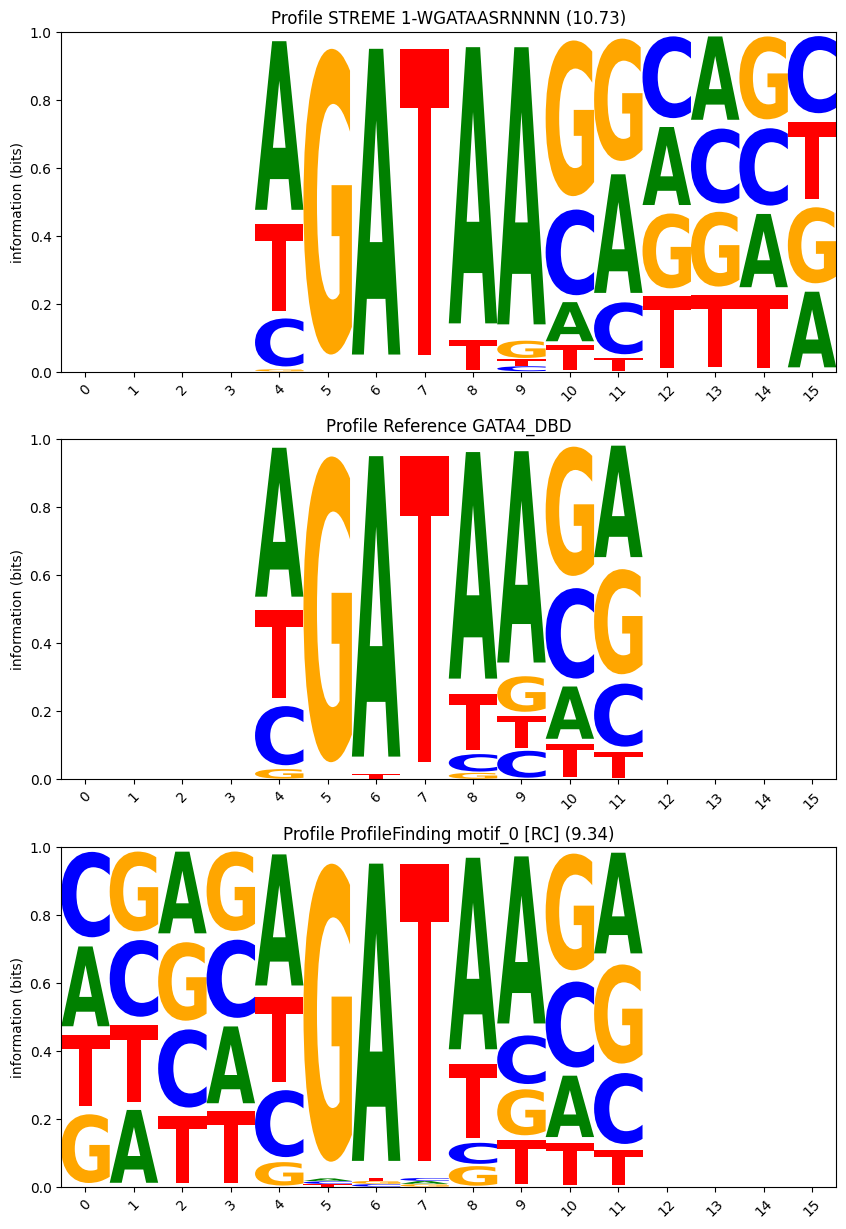

In [24]:
compare_motifs(wd / "order_0" / "uniform" / "0.80" / refs["file"].values[0],
               refs["ref"].values[0], motifs, show=True)